In [1]:
import pandas as pd
import numpy as np

C:\Users\Lehma\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import warnings
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

In [3]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [4]:
sns.set_theme(style="whitegrid", font_scale=1.0)
OUT = "outputs"
CUBS_RED = "#0E3386"
CUBS_BLUE = "#CC3433"

In [5]:
#Clean the Data
RAW_PATH = "Cubs.csv"
def load_clean():
    df = pd.read_csv(RAW_PATH, low_memory=False)
 
    # Parse date
    df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce")
    df["season"] = df["game_year"]
 
    # player_name in this export is the BATTER facing the pitch, not the pitcher.
    df = df.rename(columns={"player_name": "batter_name"})
 
    # Home vs away for the Cubs pitcher
    df["cubs_is_home"] = df["home_team"].eq("CHC")
 
    # Simplify pitch result into 5 clean outcome buckets from `description`
    swing_desc = {
        "hit_into_play", "foul", "swinging_strike", "swinging_strike_blocked",
        "foul_tip", "foul_bunt", "missed_bunt",
    }
    whiff_desc = {"swinging_strike", "swinging_strike_blocked", "foul_tip", "missed_bunt"}
 
    def bucket(row):
        d = row["description"]
        if d == "hit_into_play":
            return "hit_into_play"
        if d in whiff_desc:
            return "whiff"
        if d == "foul" or d == "foul_bunt":
            return "foul"
        if d == "called_strike":
            return "called_strike"
        if d in ("ball", "blocked_ball", "pitchout"):
            return "ball"
        if d == "hit_by_pitch":
            return "hit_by_pitch"
        return "other"
 
    df["pitch_result"] = df.apply(bucket, axis=1)
    df["swung"] = df["description"].isin(swing_desc).astype(int)
    df["whiff"] = df["description"].isin(whiff_desc).astype(int)
 
    # Count / game context
    df["count_state"] = df["balls"].astype(str) + "-" + df["strikes"].astype(str)
    df["is_two_strikes"] = (df["strikes"] == 2).astype(int)
    df["is_three_balls"] = (df["balls"] == 3).astype(int)
    df["run_diff_bat"] = df["bat_score"] - df["fld_score"]
 
    # Pitch number within the game for the pitcher (fatigue proxy), approximated
    # using at_bat_number/pitch_number ordering within game_pk+pitcher
    df = df.sort_values(["game_pk", "pitcher", "at_bat_number", "pitch_number"])
    df["pitcher_pitch_count_in_game"] = df.groupby(["game_pk", "pitcher"]).cumcount() + 1
 
    # Home run flag
    df["is_home_run"] = (df["events"] == "home_run").astype(int)
 
    # Zone: Statcast zone 1-9 = in strike zone, 11-14 = out of zone
    df["in_zone"] = df["zone"].apply(lambda z: 1 if pd.notnull(z) and z <= 9 else 0)
 
    return df

In [6]:
d = load_clean()
print(d.shape)

(25000, 131)


EDA

In [7]:
%matplotlib inline

C:\Users\Lehma\AppData\Local\Temp\ipykernel_4196\1285488685.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="season", y="release_speed", ax=axes[1], palette="Blues")


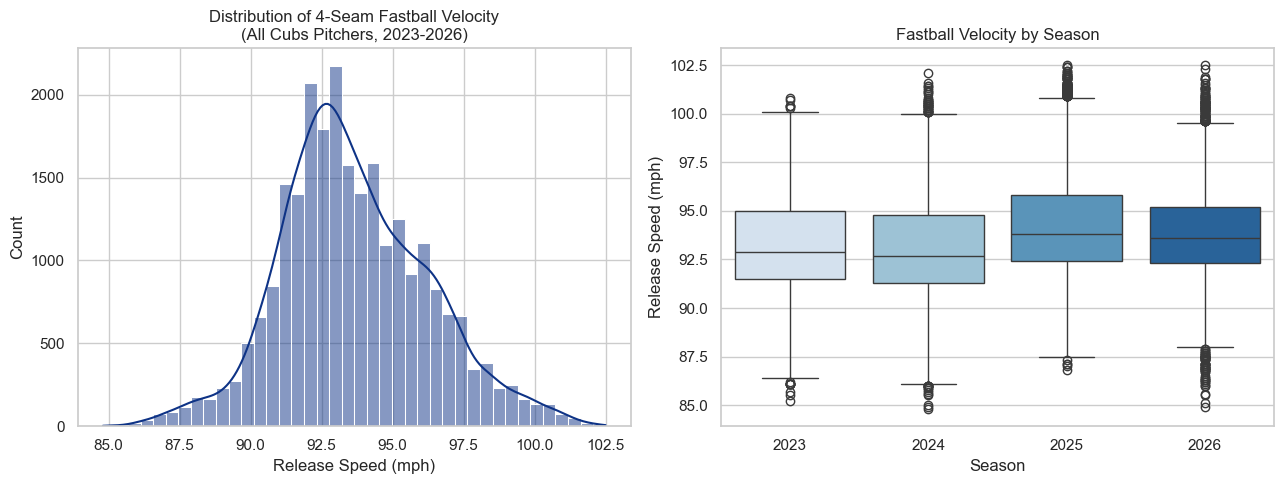

In [8]:
df = load_clean()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["release_speed"], bins=40, color=CUBS_RED, ax=axes[0], kde=True)
axes[0].set_title("Distribution of 4-Seam Fastball Velocity\n(All Cubs Pitchers, 2023-2026)")
axes[0].set_xlabel("Release Speed (mph)")
 
sns.boxplot(data=df, x="season", y="release_speed", ax=axes[1], palette="Blues")
axes[1].set_title("Fastball Velocity by Season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Release Speed (mph)")
plt.tight_layout()

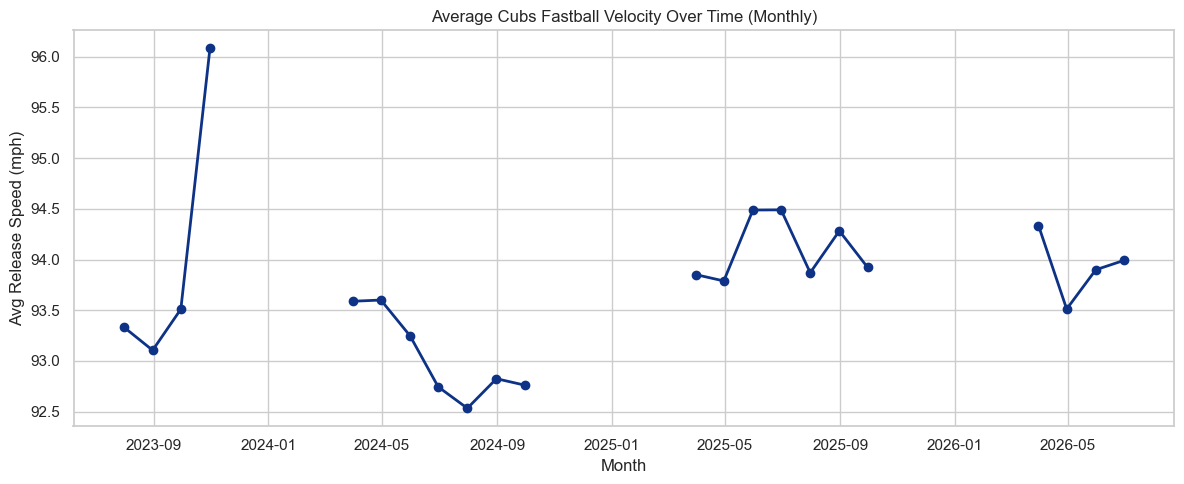

In [9]:
monthly = df.set_index("game_date").resample("ME")["release_speed"].mean()
plt.figure(figsize=(12, 5))
plt.plot(monthly.index, monthly.values, marker="o", color=CUBS_RED, linewidth=2)
plt.title("Average Cubs Fastball Velocity Over Time (Monthly)")
plt.ylabel("Avg Release Speed (mph)")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

C:\Users\Lehma\AppData\Local\Temp\ipykernel_4196\3476832395.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_velo.values, y=[str(p) for p in top_velo.index], palette="Blues_r")


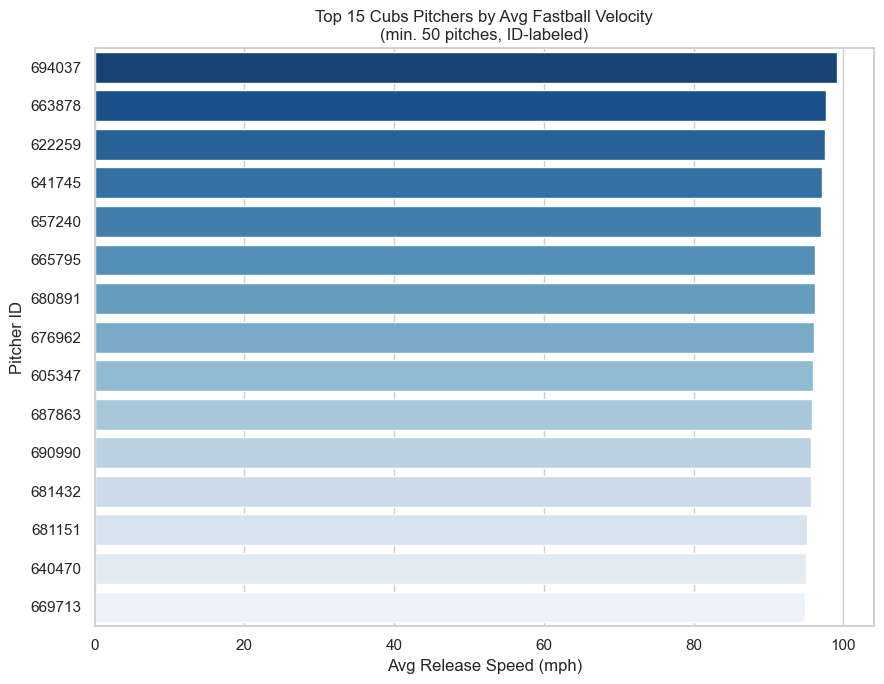

In [10]:
counts = df.groupby("pitcher").size()
qualified = counts[counts >= 50].index
top_velo = (df[df["pitcher"].isin(qualified)]
            .groupby("pitcher")["release_speed"].mean()
            .sort_values(ascending=False).head(15))
plt.figure(figsize=(9, 7))
sns.barplot(x=top_velo.values, y=[str(p) for p in top_velo.index], palette="Blues_r")
plt.title("Top 15 Cubs Pitchers by Avg Fastball Velocity\n(min. 50 pitches, ID-labeled)")
plt.xlabel("Avg Release Speed (mph)")
plt.ylabel("Pitcher ID")
plt.tight_layout()
plt.show()

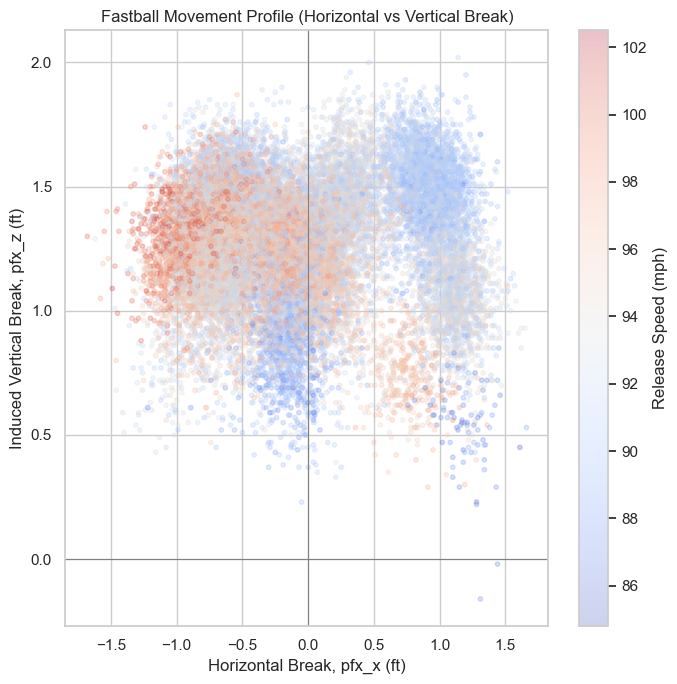

In [11]:
plt.figure(figsize=(7, 7))
sc = plt.scatter(df["pfx_x"], df["pfx_z"], c=df["release_speed"], cmap="coolwarm",
                  alpha=0.25, s=10)
plt.colorbar(sc, label="Release Speed (mph)")
plt.axhline(0, color="grey", lw=0.8)
plt.axvline(0, color="grey", lw=0.8)
plt.title("Fastball Movement Profile (Horizontal vs Vertical Break)")
plt.xlabel("Horizontal Break, pfx_x (ft)")
plt.ylabel("Induced Vertical Break, pfx_z (ft)")
plt.tight_layout()
plt.show()

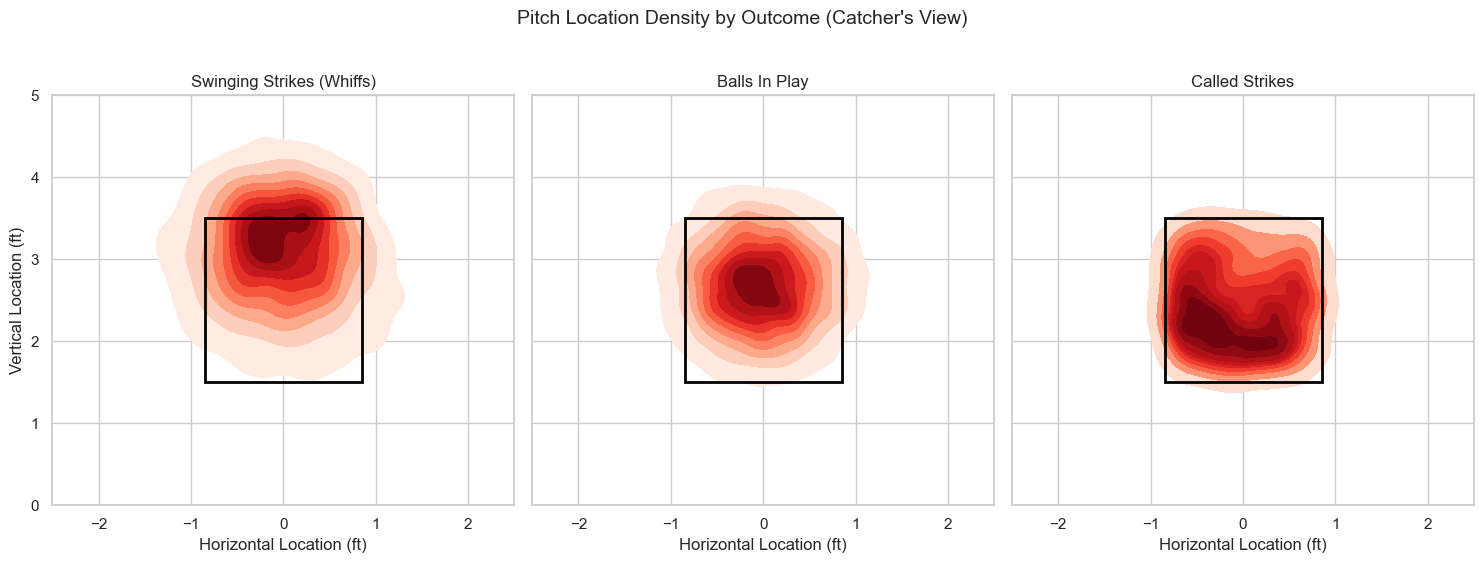

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)
zone_box = dict(xmin=-0.85, xmax=0.85, ymin=1.5, ymax=3.5)
for ax, result, title in zip(
        axes,
        ["whiff", "hit_into_play", "called_strike"],
        ["Swinging Strikes (Whiffs)", "Balls In Play", "Called Strikes"]):
    sub = df[df["pitch_result"] == result]
    sns.kdeplot(x=sub["plate_x"], y=sub["plate_z"], fill=True, cmap="Reds",
                thresh=0.05, ax=ax)
    rect = plt.Rectangle((zone_box["xmin"], zone_box["ymin"]),
                          zone_box["xmax"] - zone_box["xmin"],
                          zone_box["ymax"] - zone_box["ymin"],
                          fill=False, edgecolor="black", lw=2)
    ax.add_patch(rect)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(0, 5)
    ax.set_title(title)
    ax.set_xlabel("Horizontal Location (ft)")
axes[0].set_ylabel("Vertical Location (ft)")
plt.suptitle("Pitch Location Density by Outcome (Catcher's View)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()